In [1]:

import numpy as np
import matplotlib.pyplot as plt

data = np.load("specific_modified_gravity_ringdown_templates.npz")

times = data["times"]

hp_gr = data["hp_gr"]
hp_dcs_axial = data["hp_dcs_axial"]
hp_dcs_polar = data["hp_dcs_polar"]
hp_st = data["hp_scalar_tensor"]

dt = times[1] - times[0]

print("Loaded templates.")
print("samples:", len(times))

def analytic_psd(freqs, f0=250.0, floor=1e-46):
    f = np.maximum(freqs, 1.0)
    low = (f0 / f) ** 4
    mid = 1.0
    high = (f / (2.5 * f0)) ** 2
    return floor * (low + mid + high)

freqs = np.fft.rfftfreq(len(times), dt)
psd = analytic_psd(freqs)

def fd_inner(h1, h2):
    h1f = np.fft.rfft(h1)
    h2f = np.fft.rfft(h2)

    df = freqs[1] - freqs[0]

    return 4 * np.real(np.sum(h1f * np.conjugate(h2f) / psd) * df)

def fd_norm(h):
    return np.sqrt(np.abs(fd_inner(h, h)))

def fd_overlap(h1, h2):
    return fd_inner(h1, h2) / (fd_norm(h1) * fd_norm(h2))

def matched_filter_snr(template, data):
    return fd_inner(data, template) / fd_norm(template)

Loaded templates.
samples: 410


In [2]:

def inject_signal(signal, sigma=1e-22, seed=1):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, len(signal))
    return signal + noise

data_gr = inject_signal(hp_gr)
data_dcs = inject_signal(hp_dcs_axial)
data_st = inject_signal(hp_st)

print("Injections built.")

Injections built.


In [3]:

def recovery_summary(label, data_signal):

    ov = fd_overlap(data_signal, hp_gr)
    snr = matched_filter_snr(hp_gr, data_signal)

    print("\nInjection:", label)
    print("Overlap with GR template:", ov)
    print("Recovered SNR:", snr)

recovery_summary("GR", data_gr)
recovery_summary("dCS axial", data_dcs)
recovery_summary("Scalar-tensor", data_st)


Injection: GR
Overlap with GR template: 1.0
Recovered SNR: 2.9458267924061015e+25

Injection: dCS axial
Overlap with GR template: 0.9999966398531093
Recovered SNR: 2.945796163033743e+25

Injection: Scalar-tensor
Overlap with GR template: 0.9991788097173899
Recovered SNR: 3.1900197549070127e+25


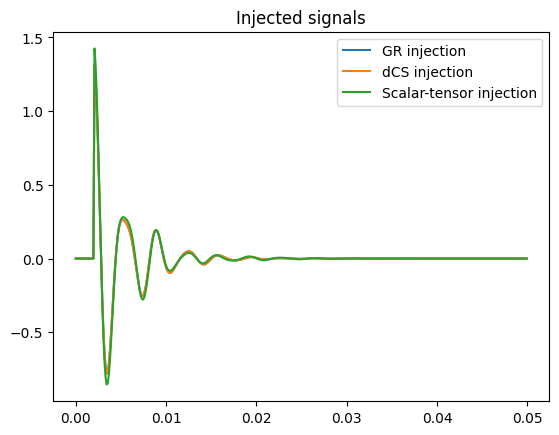

In [4]:
plt.figure()
plt.plot(times, data_gr, label="GR injection")
plt.plot(times, data_dcs, label="dCS injection")
plt.plot(times, data_st, label="Scalar-tensor injection")
plt.legend()
plt.title("Injected signals")
plt.show()

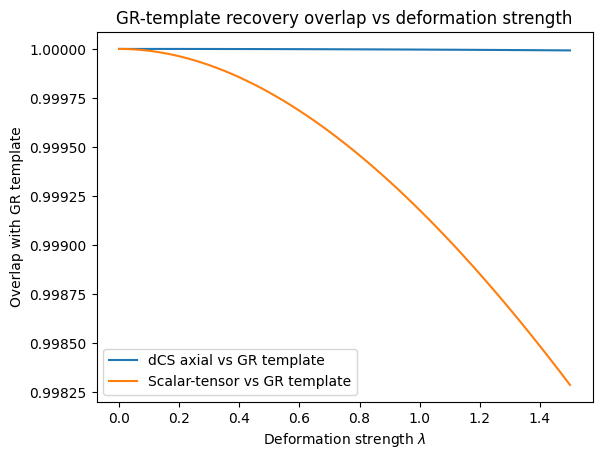

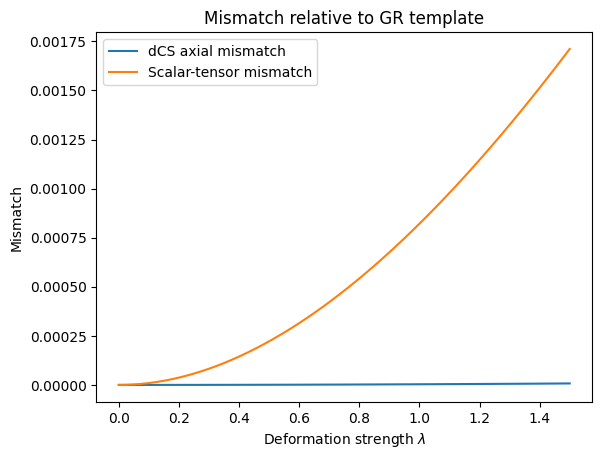

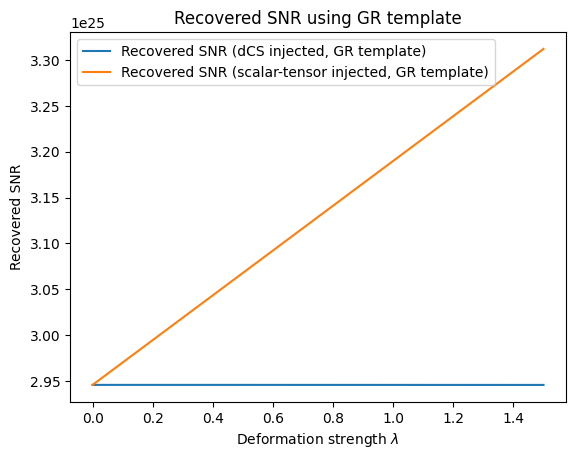


Representative dCS axial recovery values
----------------------------------------
lambda=0.00 : overlap=1.000000, mismatch=0.000000, SNR=2.945827e+25
lambda=0.38 : overlap=1.000000, mismatch=0.000000, SNR=2.945815e+25
lambda=0.75 : overlap=0.999998, mismatch=0.000002, SNR=2.945804e+25
lambda=1.12 : overlap=0.999996, mismatch=0.000004, SNR=2.945792e+25
lambda=1.50 : overlap=0.999992, mismatch=0.000008, SNR=2.945781e+25

Representative scalar-tensor recovery values
--------------------------------------------
lambda=0.00 : overlap=1.000000, mismatch=0.000000, SNR=2.945827e+25
lambda=0.38 : overlap=0.999872, mismatch=0.000128, SNR=3.037399e+25
lambda=0.75 : overlap=0.999520, mismatch=0.000480, SNR=3.128972e+25
lambda=1.12 : overlap=0.998981, mismatch=0.001019, SNR=3.220544e+25
lambda=1.50 : overlap=0.998288, mismatch=0.001712, SNR=3.312116e+25


In [5]:

def interpolate_signal(h_gr, h_mg, lam):
    """
    Interpolate between a GR waveform and a modified-gravity waveform.

    This is a practical detectability scan:
        h(lambda) = h_GR + lambda * (h_MG - h_GR)

    so:
        lambda = 0   -> GR
        lambda = 1   -> chosen MG template
    """
    return h_gr + lam * (h_mg - h_gr)


def recovery_with_gr_template(signal, noise_sigma=1e-22, seed=1):
    """
    Inject a signal into Gaussian noise and recover it with the GR template.
    Returns:
        noisy_data
        overlap_with_gr
        snr_recovered_by_gr
    """
    noisy_data = inject_signal(signal, sigma=noise_sigma, seed=seed)
    ov = fd_overlap(noisy_data, hp_gr)
    snr = matched_filter_snr(hp_gr, noisy_data)
    return noisy_data, ov, snr


lambda_vals = np.linspace(0.0, 1.5, 61)

overlaps_dcs = []
snrs_dcs = []
mismatches_dcs = []

for lam in lambda_vals:
    h_trial = interpolate_signal(hp_gr, hp_dcs_axial, lam)
    _, ov, snr = recovery_with_gr_template(h_trial, noise_sigma=1e-22, seed=1)

    overlaps_dcs.append(ov)
    snrs_dcs.append(snr)
    mismatches_dcs.append(1.0 - ov)

overlaps_dcs = np.array(overlaps_dcs)
snrs_dcs = np.array(snrs_dcs)
mismatches_dcs = np.array(mismatches_dcs)


overlaps_st = []
snrs_st = []
mismatches_st = []

for lam in lambda_vals:
    h_trial = interpolate_signal(hp_gr, hp_st, lam)
    _, ov, snr = recovery_with_gr_template(h_trial, noise_sigma=1e-22, seed=1)

    overlaps_st.append(ov)
    snrs_st.append(snr)
    mismatches_st.append(1.0 - ov)

overlaps_st = np.array(overlaps_st)
snrs_st = np.array(snrs_st)
mismatches_st = np.array(mismatches_st)


plt.figure()
plt.plot(lambda_vals, overlaps_dcs, label="dCS axial vs GR template")
plt.plot(lambda_vals, overlaps_st, label="Scalar-tensor vs GR template")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel("Overlap with GR template")
plt.title("GR-template recovery overlap vs deformation strength")
plt.legend()
plt.show()


plt.figure()
plt.plot(lambda_vals, mismatches_dcs, label="dCS axial mismatch")
plt.plot(lambda_vals, mismatches_st, label="Scalar-tensor mismatch")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel("Mismatch")
plt.title("Mismatch relative to GR template")
plt.legend()
plt.show()


plt.figure()
plt.plot(lambda_vals, snrs_dcs, label="Recovered SNR (dCS injected, GR template)")
plt.plot(lambda_vals, snrs_st, label="Recovered SNR (scalar-tensor injected, GR template)")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel("Recovered SNR")
plt.title("Recovered SNR using GR template")
plt.legend()
plt.show()


sample_indices = [0, 15, 30, 45, 60]

print("\nRepresentative dCS axial recovery values")
print("----------------------------------------")
for idx in sample_indices:
    print(
        f"lambda={lambda_vals[idx]:.2f} : "
        f"overlap={overlaps_dcs[idx]:.6f}, "
        f"mismatch={mismatches_dcs[idx]:.6f}, "
        f"SNR={snrs_dcs[idx]:.6e}"
    )

print("\nRepresentative scalar-tensor recovery values")
print("--------------------------------------------")
for idx in sample_indices:
    print(
        f"lambda={lambda_vals[idx]:.2f} : "
        f"overlap={overlaps_st[idx]:.6f}, "
        f"mismatch={mismatches_st[idx]:.6f}, "
        f"SNR={snrs_st[idx]:.6e}"
    )


Single-shot likelihood comparisons
----------------------------------

GR injection
logL(GR) = -3.633234e+06
logL(MG) = -3.633234e+06
Delta logL = 0.000000e+00

dCS axial injection
logL(GR) = -2.915901e+45
logL(MG) = -3.101793e+06
Delta logL = 2.915901e+45

Scalar-tensor injection
logL(GR) = -3.818202e+48
logL(MG) = -4.687668e+05
Delta logL = 3.818202e+48


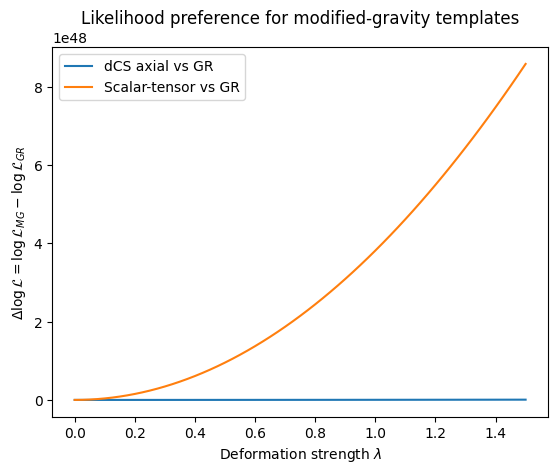

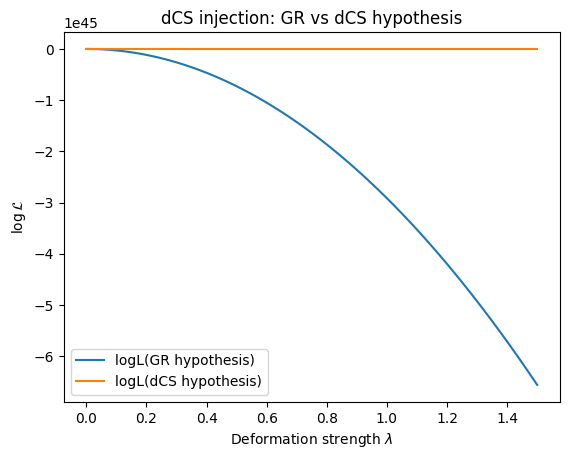

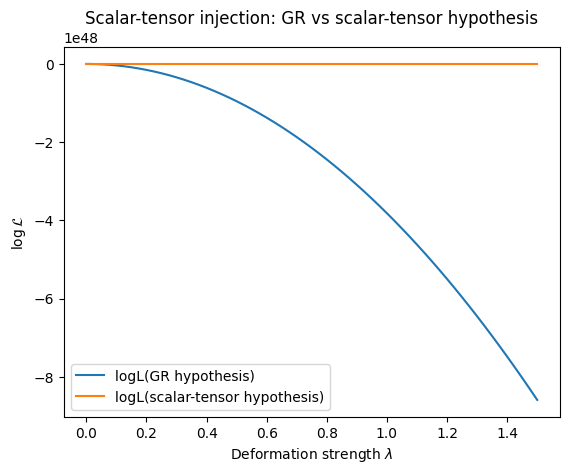


Representative delta logL values for dCS
----------------------------------------
lambda=0.00 : delta logL = 0.000000e+00
lambda=0.38 : delta logL = 4.100486e+44
lambda=0.75 : delta logL = 1.640194e+45
lambda=1.12 : delta logL = 3.690438e+45
lambda=1.50 : delta logL = 6.560778e+45

Representative delta logL values for scalar-tensor
--------------------------------------------------
lambda=0.00 : delta logL = 0.000000e+00
lambda=0.38 : delta logL = 5.369347e+47
lambda=0.75 : delta logL = 2.147739e+48
lambda=1.12 : delta logL = 4.832412e+48
lambda=1.50 : delta logL = 8.590955e+48


In [6]:

def log_likelihood(data, template):
    """
    Simple stationary-Gaussian frequency-domain log likelihood:
        logL = -1/2 <d-h | d-h>
    up to an irrelevant additive constant.
    """
    resid = data - template
    return -0.5 * fd_inner(resid, resid)


def compare_hypotheses(data, template_gr, template_mg):
    """
    Compare GR and MG explanations for the same data.
    Returns:
        logL_gr
        logL_mg
        delta_logL = logL_mg - logL_gr
    """
    logL_gr = log_likelihood(data, template_gr)
    logL_mg = log_likelihood(data, template_mg)
    delta_logL = logL_mg - logL_gr
    return logL_gr, logL_mg, delta_logL


print("\nSingle-shot likelihood comparisons")
print("----------------------------------")

for label, injected_data, template_mg in [
    ("GR injection", data_gr, hp_gr),
    ("dCS axial injection", data_dcs, hp_dcs_axial),
    ("Scalar-tensor injection", data_st, hp_st),
]:
    logL_gr, logL_mg, delta_logL = compare_hypotheses(injected_data, hp_gr, template_mg)
    print(f"\n{label}")
    print(f"logL(GR) = {logL_gr:.6e}")
    print(f"logL(MG) = {logL_mg:.6e}")
    print(f"Delta logL = {delta_logL:.6e}")


delta_logL_dcs = []
logL_gr_dcs = []
logL_mg_dcs = []

for lam in lambda_vals:
    h_trial = interpolate_signal(hp_gr, hp_dcs_axial, lam)
    noisy_trial = inject_signal(h_trial, sigma=1e-22, seed=1)

    logL_gr, logL_mg, delta_logL = compare_hypotheses(noisy_trial, hp_gr, h_trial)

    logL_gr_dcs.append(logL_gr)
    logL_mg_dcs.append(logL_mg)
    delta_logL_dcs.append(delta_logL)

delta_logL_dcs = np.array(delta_logL_dcs)
logL_gr_dcs = np.array(logL_gr_dcs)
logL_mg_dcs = np.array(logL_mg_dcs)


delta_logL_st = []
logL_gr_st = []
logL_mg_st = []

for lam in lambda_vals:
    h_trial = interpolate_signal(hp_gr, hp_st, lam)
    noisy_trial = inject_signal(h_trial, sigma=1e-22, seed=1)

    logL_gr, logL_mg, delta_logL = compare_hypotheses(noisy_trial, hp_gr, h_trial)

    logL_gr_st.append(logL_gr)
    logL_mg_st.append(logL_mg)
    delta_logL_st.append(delta_logL)

delta_logL_st = np.array(delta_logL_st)
logL_gr_st = np.array(logL_gr_st)
logL_mg_st = np.array(logL_mg_st)


plt.figure()
plt.plot(lambda_vals, delta_logL_dcs, label="dCS axial vs GR")
plt.plot(lambda_vals, delta_logL_st, label="Scalar-tensor vs GR")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel(r"$\Delta \log \mathcal{L} = \log \mathcal{L}_{MG} - \log \mathcal{L}_{GR}$")
plt.title("Likelihood preference for modified-gravity templates")
plt.legend()
plt.show()


plt.figure()
plt.plot(lambda_vals, logL_gr_dcs, label="logL(GR hypothesis)")
plt.plot(lambda_vals, logL_mg_dcs, label="logL(dCS hypothesis)")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel(r"$\log \mathcal{L}$")
plt.title("dCS injection: GR vs dCS hypothesis")
plt.legend()
plt.show()


plt.figure()
plt.plot(lambda_vals, logL_gr_st, label="logL(GR hypothesis)")
plt.plot(lambda_vals, logL_mg_st, label="logL(scalar-tensor hypothesis)")
plt.xlabel(r"Deformation strength $\lambda$")
plt.ylabel(r"$\log \mathcal{L}$")
plt.title("Scalar-tensor injection: GR vs scalar-tensor hypothesis")
plt.legend()
plt.show()


print("\nRepresentative delta logL values for dCS")
print("----------------------------------------")
for idx in sample_indices:
    print(f"lambda={lambda_vals[idx]:.2f} : delta logL = {delta_logL_dcs[idx]:.6e}")

print("\nRepresentative delta logL values for scalar-tensor")
print("--------------------------------------------------")
for idx in sample_indices:
    print(f"lambda={lambda_vals[idx]:.2f} : delta logL = {delta_logL_st[idx]:.6e}")